In [87]:
import numpy as np
import matplotlib.pyplot as plt
import scipy as sc
from scipy.constants import G
from IPython.display import clear_output
import time

In [88]:
def newton_force(coords1:np.ndarray, mass1:float, coords2:np.ndarray, mass2:float) -> float:
    r = np.linalg.norm(coords1 - coords2)
    F = G*(mass1*mass2)/(r**2)
    return F


In [89]:
def initial_plot(coords:list) -> None:
    fig = plt.figure()
    ax = fig.add_subplot(projection="3d")
    ax.set(xlim3d=(-1.5e11, 1.5e11), xlabel='X')
    ax.set(ylim3d=(-1.5e11, 1.5e11), ylabel='Y')
    ax.set(zlim3d=(-1.5e11, 1.5e11), zlabel='Z')
    for t in coords:
        ax.scatter(t[0], t[1], t[2])
    plt.show()


In [90]:
def update_location(coords:list, velocities:list, masses:list, dt) -> tuple:
    # Unpack values    
    x1 = coords[0]
    x2 = coords[1]

    # Calculate unit vectors in the direction of the force
    r1 = (x2 - x1) / np.linalg.norm(x2 - x1)
    r2 = -r1

    m1 = masses[0]
    m2 = masses[1]

    v1 = velocities[0]
    v2 = velocities[1]

    # Calculate the gravitational force magnitude
    F = newton_force(x1, m1, x2, m2)

    # Calculate acceleration magnitudes
    a1 = F / m1
    a2 = F / m2

    # Update velocities using the acceleration (note the dt factor)
    v1_new = v1 + a1 * dt * r1
    v2_new = v2 + a2 * dt * r2

    # Update positions using current velocities
    x1_new = x1 + v1_new * dt
    x2_new = x2 + v2_new * dt

    return [x1_new, x2_new], [v1_new, v2_new]


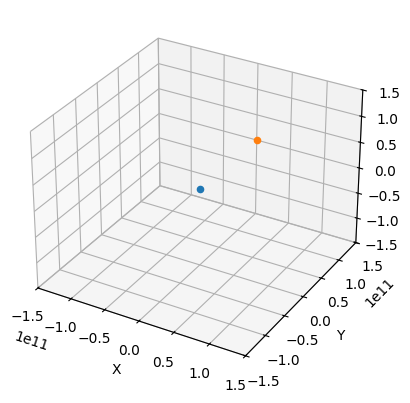

In [91]:
coords = [np.array([0, 0, 0], dtype=float), np.array([0, 1.5e11, 0], dtype=float)]
velocities = [np.array([0, 0, 0], dtype=float), np.array([0, 0, 30000], dtype=float)]
masses = [1.989e30, 5.972e24]
initial_plot(coords)

In [92]:
coords, velocities = update_location(coords, velocities, masses, 0.0001)

coords, velocities

([array([0.00000000e+00, 1.77150754e-16, 0.00000000e+00]),
  array([0.0e+00, 1.5e+11, 3.0e+00])],
 [array([0.00000000e+00, 1.77150754e-12, 0.00000000e+00]),
  array([ 0.0000000e+00, -5.9000812e-07,  3.0000000e+04])])

In [93]:
while True:
    coords, velocities = update_location(coords, velocities, masses, 10000)
    initial_plot(coords)
    clear_output(wait=True)

KeyboardInterrupt: 